In [109]:
# inisialisasi library yang dipakai untuk model yang akan dilatih 
import pandas as pd
import numpy as np
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib 
from pathlib import Path
import time
import matplotlib.pyplot as plt
import sys

sys.path.append("..")
from feature_engineering import load_raw_data, build_features, save_encoders, FEATURES, TARGET

print(repr(TARGET))
print(repr(FEATURES))

BASE_DIR = Path("..").resolve()
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
TRAINED_MODELS = BASE_DIR / "trained_models"

for folder in (DATA_PROCESSED, TRAINED_MODELS):
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 140)

# nandain model keseluruhan 
GENERAL_SCOPE = "ALL"
MIN_ROWS_PER_SCOPE = 50


'SALES_QTY'
['Tahun', 'Bulan', 'Sales_t-1', 'Sales_t-2', 'Sales_t-3', 'Ma_3', 'Ma_6']


In [110]:
# input dan analisis data yang ada 
df_raw = load_raw_data(DATA_RAW / "datarofo.xlsx")


print(f"Jumlah baris : {df_raw.shape[0]}")
print(f"Jumlah kolom : {df_raw.shape[1]}")
print(f"\nJumlah produk unik : {df_raw['KODE_PRODUK'].nunique()}")
print(f"Jumlah LOB unik    : {df_raw['LOB'].nunique()}")

print("\nJumlah baris & produk per LOB:")
ringkasan_lob = df_raw.groupby("LOB").agg(
    jumlah_baris=("KODE_PRODUK", "size"),
    jumlah_produk=("KODE_PRODUK", "nunique"),
)
ringkasan_lob

Jumlah baris : 22699
Jumlah kolom : 5

Jumlah produk unik : 1313
Jumlah LOB unik    : 7

Jumlah baris & produk per LOB:


,jumlah_baris,jumlah_produk
LOB,,
2CPSH,345,20
2GRSY,5589,323
2HBLE,10781,624
2HIQL,2175,126
2HSPH,2564,148
2LPCM,708,41
2VIOS,537,31


In [111]:
# prapemrosesan data dan feature engineering 
# manggil feature.engineering.py juga buat melakukan feature engineering 

# pemodelan dan pelatihan model ketiga algoritma
# fungsi buat smape karna gabisa langsung consume dari sklearn metric

from numpy import log2

def smape (y_true, y_pred, eps=1e-9):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    denom = np.where(denom == 0, eps, denom)
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100)

def model_filename(algorithm_name: str, scope: str) -> str:
    return f"{algorithm_name}_{scope}.joblib"

def encoder_filename(scope: str) -> str:
    return f"encoders_{scope}.joblib"

# ini default punya 
# MODEL_CLASSES = {
#     "Random Forest Regression": ("random_forest", lambda: RandomForestRegressor(
#         n_estimators=300, random_state=42, n_jobs=-1)),
#     "Extra Trees Regression": ("extra_trees", lambda: ExtraTreesRegressor(
#         n_estimators=300, random_state=42, n_jobs=-1)),
#     "Gradient Boosting Regression": ("gradient_boosting", lambda: GradientBoostingRegressor(
#         n_estimators=300, learning_rate=0.01, max_depth=3, random_state=42)),
# }

# hasil tuning hyperparameter ini paling oke mantapszs
MODEL_CLASSES = {
    "Random Forest Regression": ("random_forest", lambda: RandomForestRegressor(
        n_estimators= 100, random_state=42, min_samples_split= 5, min_samples_leaf= 2, max_features= 'log2', max_depth= 10)),
    "Extra Trees Regression": ("extra_trees", lambda: ExtraTreesRegressor(
        n_estimators= 100, random_state=42,min_samples_split= 5, min_samples_leaf= 2, max_features= 'log2', max_depth= 10)),
    "Gradient Boosting Regression": ("gradient_boosting", lambda: GradientBoostingRegressor(
        subsample= 0.6, n_estimators= 300, random_state=42,min_samples_split= 10, min_samples_leaf= 1, max_depth= 2, learning_rate= 0.03)),
}

# latih keseluruhan produk tanpa pisah per LOB
def train_satu_model_keseluruhan(df_scope: pd.DataFrame, scope: str, verbose=False):
    df_model, encoders = build_features(df_scope, fit=True, verbose=verbose)
    df_model = df_model.sort_values("PERIOD_MO").reset_index(drop=True)

    if len(df_model) < MIN_ROWS_PER_SCOPE:
        print(f"[{scope}] dilewati: hanya {len(df_model)} baris setelah feature engineering (< {MIN_ROWS_PER_SCOPE}).")
        return []

    unique_periods = sorted(df_model["PERIOD_MO"].unique())
    if len(unique_periods) < 2:
        print(f"[{scope}] dilewati: jumlah periode unik tidak cukup untuk split train/test.")
        return []

    cutoff_date = unique_periods[int(len(unique_periods) * 0.8)]
    train_df = df_model[df_model["PERIOD_MO"] < cutoff_date]
    test_df = df_model[df_model["PERIOD_MO"] >= cutoff_date]
    if len(train_df) == 0 or len(test_df) == 0:
        print(f"[{scope}] dilewati: data train/test kosong setelah split.")
        return []

    X_train, y_train = train_df[FEATURES], train_df[TARGET]
    X_test, y_test = test_df[FEATURES], test_df[TARGET]

    hasil = []
    for nama_model, (algo_key, make_model) in MODEL_CLASSES.items():
        start = time.time()
        model = make_model()
        model.fit(X_train, y_train)
        elapsed = time.time() - start

        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
        smape_val = smape(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        joblib.dump(model, TRAINED_MODELS / model_filename(algo_key, scope))

        hasil.append({
            "Scope": scope,
            "Model": nama_model,
            "MAE": mae,
            "RMSE": rmse,
            "sMAPE (%)": smape_val,
            "R2 Score": r2,
            "Waktu Latih (s)": elapsed,
            "Jumlah Data Latih": len(train_df),
        })

    save_encoders(encoders, TRAINED_MODELS / encoder_filename(scope))
    print(f"[{scope}] selesai dilatih ({len(train_df)} data latih, {len(test_df)} data uji).")
    return hasil


In [112]:
# buat latih model per LOB 
# ada 7 LOB

daftar_lob = sorted(df_raw["LOB"].dropna().unique())
print(f"LOB yang akan dilatih terpisah: {daftar_lob}")

semua_hasil = []

# 1. Model satu keseluruhan untuk semua produk
print("\n--- Melatih model keseluruhan produk tanpa pisah LOB ---")
semua_hasil += train_satu_model_keseluruhan(df_raw.copy(), scope=GENERAL_SCOPE)

# 2. Model PER LOB
print("\n--- Melatih model PER LOB ---")
for lob in daftar_lob:
    df_lob = df_raw[df_raw["LOB"] == lob].copy()
    semua_hasil += train_satu_model_keseluruhan(df_lob, scope=lob)

print(f"\nTotal kombinasi satu model keselurhan + LOB berhasil dilatih: {len(semua_hasil)}")

LOB yang akan dilatih terpisah: ['2CPSH', '2GRSY', '2HBLE', '2HIQL', '2HSPH', '2LPCM', '2VIOS']

--- Melatih model keseluruhan produk tanpa pisah LOB ---
[ALL] selesai dilatih (19671 data latih, 5252 data uji).

--- Melatih model PER LOB ---
[2CPSH] selesai dilatih (300 data latih, 80 data uji).
[2GRSY] selesai dilatih (4833 data latih, 1292 data uji).
[2HBLE] selesai dilatih (9348 data latih, 2496 data uji).
[2HIQL] selesai dilatih (1890 data latih, 504 data uji).
[2HSPH] selesai dilatih (2220 data latih, 592 data uji).
[2LPCM] selesai dilatih (615 data latih, 164 data uji).
[2VIOS] selesai dilatih (465 data latih, 124 data uji).

Total kombinasi satu model keselurhan + LOB berhasil dilatih: 24


In [113]:
# evaluasi dan output 
results_df = pd.DataFrame(semua_hasil)
results_df = results_df[["Scope", "Model", "MAE", "RMSE", "sMAPE (%)", "R2 Score", "Jumlah Data Latih"]]
results_df = results_df.sort_values(["Scope", "Model"]).reset_index(drop=True)

results_df.to_csv(DATA_PROCESSED / "hasil_evaluasi_model_per_lob.csv", index=False)
print(f"Tabel evaluasi lengkap disimpan di: {DATA_PROCESSED / 'hasil_evaluasi_model_per_lob.csv'}")
results_df.round(3)

Tabel evaluasi lengkap disimpan di: C:\Users\mmeli\forecasting-app-skripsi\backend\ml\data\processed\hasil_evaluasi_model_per_lob.csv


,Scope,Model,MAE,RMSE,sMAPE (%),R2 Score,Jumlah Data Latih
0,2CPSH,Extra Trees Regression,4868.443,30125.676,194.783,0.022,300
1,2CPSH,Gradient Boosting Regression,5912.726,29872.034,196.702,0.039,300
2,2CPSH,Random Forest Regression,5729.523,29892.663,46.531,0.037,300
3,2GRSY,Extra Trees Regression,1386.436,17517.049,191.877,0.006,4833
4,2GRSY,Gradient Boosting Regression,1582.762,17488.254,193.121,0.010,4833
5,2GRSY,Random Forest Regression,1571.521,17489.269,43.078,0.010,4833
6,2HBLE,Extra Trees Regression,1992.367,24403.660,192.355,0.004,9348
7,2HBLE,Gradient Boosting Regression,2194.822,24350.496,193.528,0.009,9348
8,2HBLE,Random Forest Regression,2210.300,24347.636,43.579,0.009,9348
9,2HIQL,Extra Trees Regression,1068.365,6069.798,192.504,0.036,1890


In [114]:
# model terbaik per apa yang diambil 
best_per_scope = results_df.loc[results_df.groupby("Scope")["RMSE"].idxmin()]
best_per_scope = best_per_scope[["Scope", "Model", "MAE", "RMSE", "sMAPE (%)", "R2 Score"]].reset_index(drop=True)
best_per_scope.round(3)

,Scope,Model,MAE,RMSE,sMAPE (%),R2 Score
0,2CPSH,Gradient Boosting Regression,5912.726,29872.034,196.702,0.039
1,2GRSY,Gradient Boosting Regression,1582.762,17488.254,193.121,0.010
2,2HBLE,Random Forest Regression,2210.300,24347.636,43.579,0.009
3,2HIQL,Random Forest Regression,1234.531,6060.658,43.278,0.039
4,2HSPH,Random Forest Regression,3351.858,28529.244,45.402,0.014
5,2LPCM,Extra Trees Regression,1682.726,3265.048,195.693,-3.477
6,2VIOS,Random Forest Regression,1646.080,6957.087,43.444,0.068
7,ALL,Gradient Boosting Regression,2122.020,21621.285,193.844,0.011


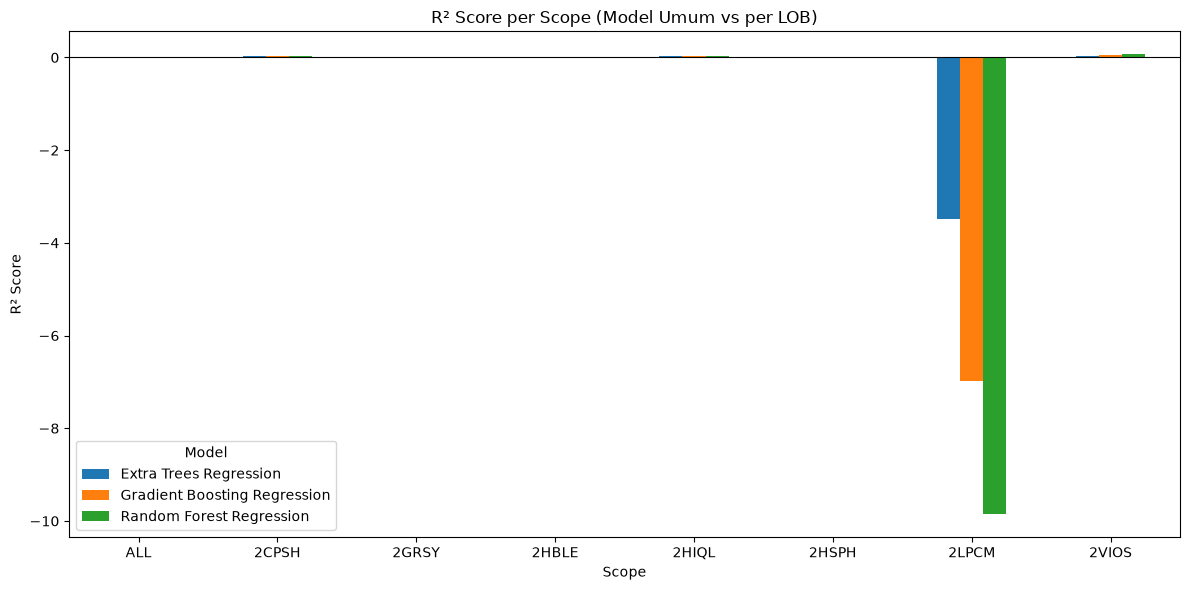

In [115]:
# perbandingan model satu keseluruhan dan misal perLOB
# apa lebih oke satu keseluruhan atau per LOB 
fig, ax = plt.subplots(figsize=(12, 6))
pivot_r2 = results_df.pivot(index="Scope", columns="Model", values="R2 Score")
# model satu keseluruhan di taro pling kiri sebagai pembanding
order = [GENERAL_SCOPE] + [s for s in pivot_r2.index if s != GENERAL_SCOPE]
pivot_r2.loc[order].plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("R² Score per Scope (Model Umum vs per LOB)")
ax.set_ylabel("R² Score")
ax.set_xlabel("Scope")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "r2_perbandingan_scope.png", dpi=150)
plt.show()

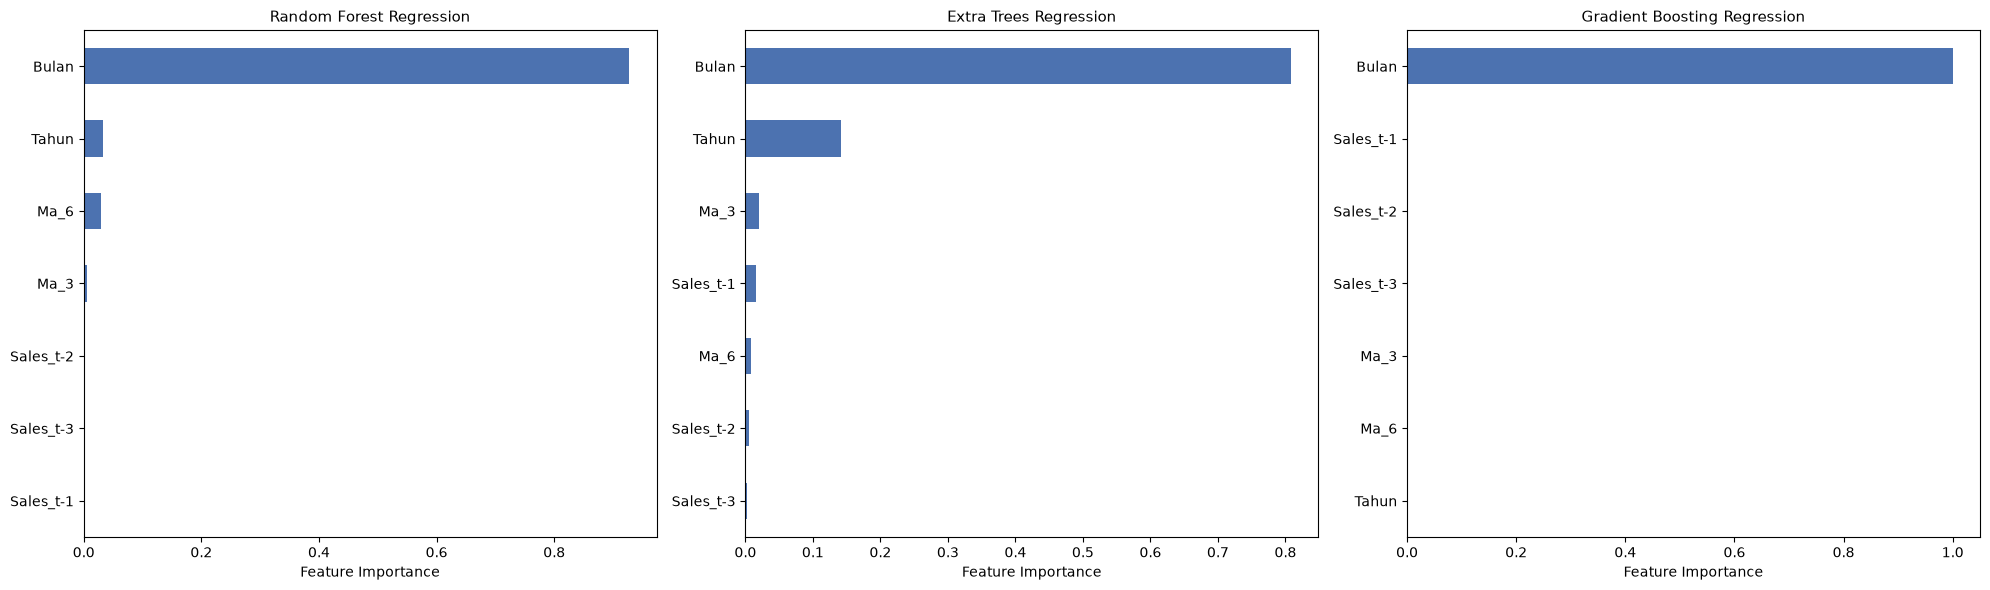

In [116]:
import joblib as _joblib

# feature importance pada tiap fitur yang digunakan
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (nama_model, (algo_key, _)) in zip(axes, MODEL_CLASSES.items()):
    model = _joblib.load(TRAINED_MODELS / model_filename(algo_key, GENERAL_SCOPE))
    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    importances.plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_title(nama_model, fontsize=11)
    ax.set_xlabel("Feature Importance")

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "feature_importance_model_umum.png", dpi=150)
plt.show()


In [117]:
#  forecast yang tiap prediksi dipake lagi untuk prediksi kedepannya ini buat yang t+6 bulan itu
# pake random forest ini 
from feature_engineering import (
    forecast_month, handle_negative_sales, fix_period_bug,
    aggregate_monthly, fill_monthly_gaps,
)

produk_contoh = df_raw["KODE_PRODUK"].value_counts().index[0]  # produk dengan histori terbanyak
hist_lengkap = fix_period_bug(handle_negative_sales(df_raw[df_raw["KODE_PRODUK"] == produk_contoh].copy(), verbose=False))

hist_lengkap = aggregate_monthly(hist_lengkap, verbose=False)
hist_lengkap = fill_monthly_gaps(hist_lengkap, verbose=False)
hist_lengkap = hist_lengkap.sort_values("PERIOD_MO").reset_index(drop=True)

print(f"Produk contoh: {produk_contoh}")
print("6 bulan histori terakhir:")
print(hist_lengkap[["PERIOD_MO", "SALES_QTY"]].tail(6))

model_umum = joblib.load(TRAINED_MODELS / "random_forest_ALL.joblib")
history_values = hist_lengkap["SALES_QTY"].tolist()
last_period = hist_lengkap["PERIOD_MO"].max()

forecast = forecast_month(model_umum, history_values, last_period, horizon=6)

print("\nForecast 6 bulan ke depan:")
forecast_df = pd.DataFrame(forecast)
forecast_df

Produk contoh: PRD0001
6 bulan histori terakhir:
    PERIOD_MO  SALES_QTY
19 2024-08-01        0.0
20 2024-09-01        0.0
21 2024-10-01        0.0
22 2024-11-01        0.0
23 2024-12-01        0.0
24 2025-01-01       68.0

Forecast 6 bulan ke depan:


,tahun,bulan,predicted_quantity
0,2025,2,0.0
1,2025,3,0.0
2,2025,4,0.0
3,2025,5,0.0
4,2025,6,0.0
5,2025,7,0.0


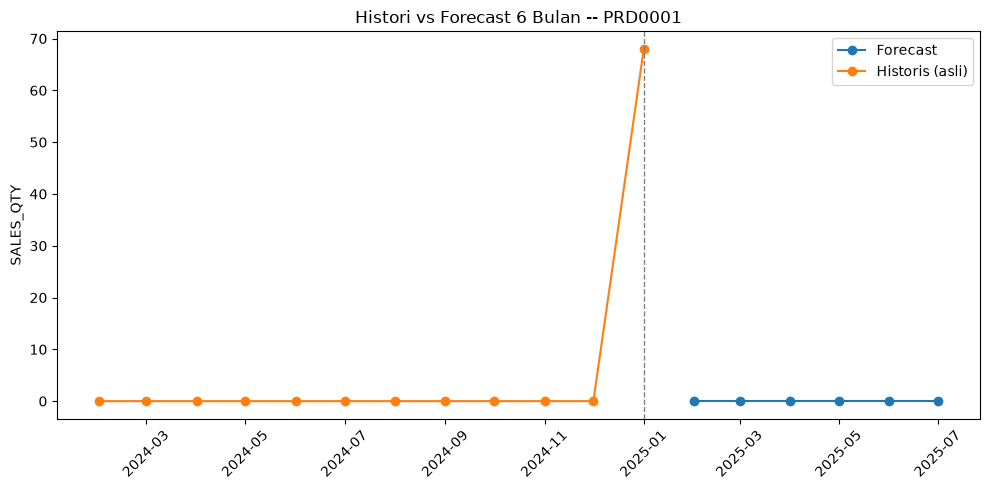

In [118]:
fig, ax = plt.subplots(figsize=(10, 5))
hist_plot = hist_lengkap[["PERIOD_MO", "SALES_QTY"]].tail(12).rename(columns={"SALES_QTY": "value"})
hist_plot["tipe"] = "Historis (asli)"

forecast_plot = forecast_df.copy()
forecast_plot["PERIOD_MO"] = pd.to_datetime(
    forecast_plot["tahun"].astype(str) + "-" + forecast_plot["bulan"].astype(str) + "-01"
)
forecast_plot = forecast_plot.rename(columns={"predicted_quantity": "value"})[["PERIOD_MO", "value"]]
forecast_plot["tipe"] = "Forecast"

gabungan = pd.concat([hist_plot[["PERIOD_MO", "value", "tipe"]], forecast_plot])
for tipe, g in gabungan.groupby("tipe"):
    ax.plot(g["PERIOD_MO"], g["value"], marker="o", label=tipe)

ax.axvline(hist_lengkap["PERIOD_MO"].max(), color="gray", linestyle="--", linewidth=1)
ax.set_title(f"Histori vs Forecast 6 Bulan -- {produk_contoh}")
ax.set_ylabel("SALES_QTY")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "contoh_forecast_6bulankedepan.png", dpi=150)
plt.show()

In [119]:
#  nyoba pake gradient boosting
from feature_engineering import (
    forecast_month, handle_negative_sales, fix_period_bug,
    aggregate_monthly, fill_monthly_gaps,
)

produk_contoh = df_raw["KODE_PRODUK"].value_counts().index[0]  # produk dengan histori terbanyak
hist_lengkap = fix_period_bug(handle_negative_sales(df_raw[df_raw["KODE_PRODUK"] == produk_contoh].copy(), verbose=False))

hist_lengkap = aggregate_monthly(hist_lengkap, verbose=False)
hist_lengkap = fill_monthly_gaps(hist_lengkap, verbose=False)
hist_lengkap = hist_lengkap.sort_values("PERIOD_MO").reset_index(drop=True)

print(f"Produk contoh: {produk_contoh}")
print("6 bulan histori terakhir:")
print(hist_lengkap[["PERIOD_MO", "SALES_QTY"]].tail(6))

model_umum = joblib.load(TRAINED_MODELS / "gradient_boosting_ALL.joblib")
history_values = hist_lengkap["SALES_QTY"].tolist()
last_period = hist_lengkap["PERIOD_MO"].max()

forecast = forecast_month(model_umum, history_values, last_period, horizon=6)

print("\nForecast 6 bulan ke depan:")
forecast_df = pd.DataFrame(forecast)
forecast_df

Produk contoh: PRD0001
6 bulan histori terakhir:
    PERIOD_MO  SALES_QTY
19 2024-08-01        0.0
20 2024-09-01        0.0
21 2024-10-01        0.0
22 2024-11-01        0.0
23 2024-12-01        0.0
24 2025-01-01       68.0

Forecast 6 bulan ke depan:


,tahun,bulan,predicted_quantity
0,2025,2,0.03
1,2025,3,0.03
2,2025,4,0.03
3,2025,5,0.03
4,2025,6,0.03
5,2025,7,0.03


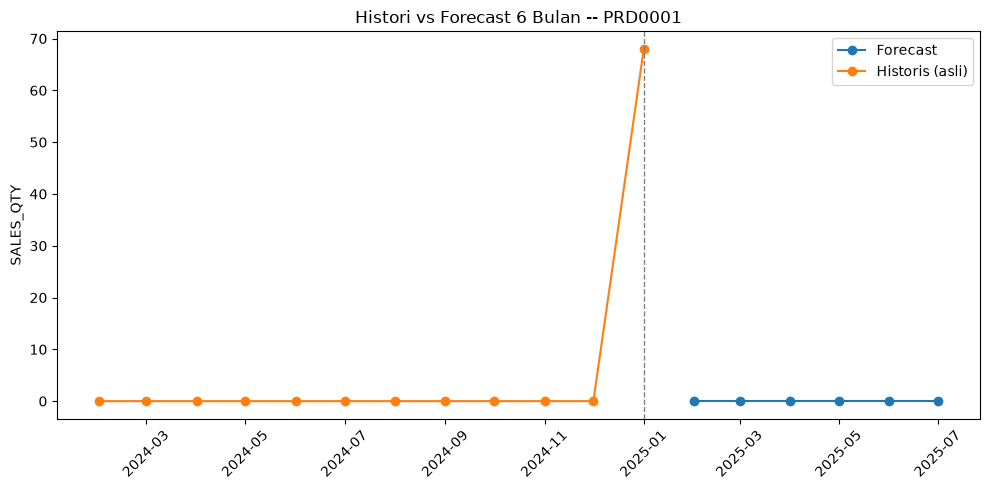

In [120]:
fig, ax = plt.subplots(figsize=(10, 5))
hist_plot = hist_lengkap[["PERIOD_MO", "SALES_QTY"]].tail(12).rename(columns={"SALES_QTY": "value"})
hist_plot["tipe"] = "Historis (asli)"

forecast_plot = forecast_df.copy()
forecast_plot["PERIOD_MO"] = pd.to_datetime(
    forecast_plot["tahun"].astype(str) + "-" + forecast_plot["bulan"].astype(str) + "-01"
)
forecast_plot = forecast_plot.rename(columns={"predicted_quantity": "value"})[["PERIOD_MO", "value"]]
forecast_plot["tipe"] = "Forecast"

gabungan = pd.concat([hist_plot[["PERIOD_MO", "value", "tipe"]], forecast_plot])
for tipe, g in gabungan.groupby("tipe"):
    ax.plot(g["PERIOD_MO"], g["value"], marker="o", label=tipe)

ax.axvline(hist_lengkap["PERIOD_MO"].max(), color="gray", linestyle="--", linewidth=1)
ax.set_title(f"Histori vs Forecast 6 Bulan -- {produk_contoh}")
ax.set_ylabel("SALES_QTY")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "contoh_forecast_6bulankedepan.png", dpi=150)
plt.show()

In [121]:
#  nyoba pake extra trees
from feature_engineering import (
    forecast_month, handle_negative_sales, fix_period_bug,
    aggregate_monthly, fill_monthly_gaps,
)

produk_contoh = df_raw["KODE_PRODUK"].value_counts().index[0]  # produk dengan histori terbanyak
hist_lengkap = fix_period_bug(handle_negative_sales(df_raw[df_raw["KODE_PRODUK"] == produk_contoh].copy(), verbose=False))

hist_lengkap = aggregate_monthly(hist_lengkap, verbose=False)
hist_lengkap = fill_monthly_gaps(hist_lengkap, verbose=False)
hist_lengkap = hist_lengkap.sort_values("PERIOD_MO").reset_index(drop=True)

print(f"Produk contoh: {produk_contoh}")
print("6 bulan histori terakhir:")
print(hist_lengkap[["PERIOD_MO", "SALES_QTY"]].tail(6))

model_umum = joblib.load(TRAINED_MODELS / "extra_trees_ALL.joblib")
history_values = hist_lengkap["SALES_QTY"].tolist()
last_period = hist_lengkap["PERIOD_MO"].max()

forecast = forecast_month(model_umum, history_values, last_period, horizon=6)

print("\nForecast 6 bulan ke depan:")
forecast_df = pd.DataFrame(forecast)
forecast_df

Produk contoh: PRD0001
6 bulan histori terakhir:
    PERIOD_MO  SALES_QTY
19 2024-08-01        0.0
20 2024-09-01        0.0
21 2024-10-01        0.0
22 2024-11-01        0.0
23 2024-12-01        0.0
24 2025-01-01       68.0

Forecast 6 bulan ke depan:


,tahun,bulan,predicted_quantity
0,2025,2,409.38
1,2025,3,166.26
2,2025,4,129.54
3,2025,5,81.41
4,2025,6,78.41
5,2025,7,53.78


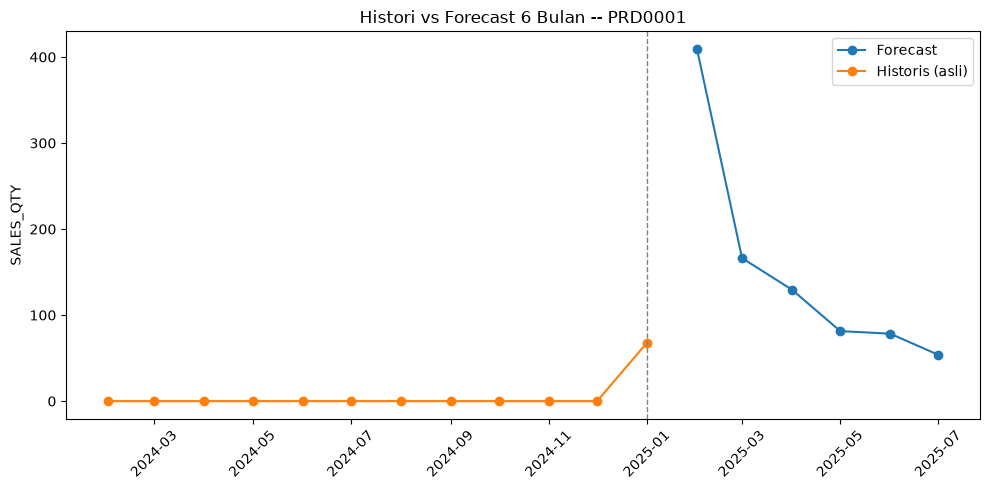

In [122]:
fig, ax = plt.subplots(figsize=(10, 5))
hist_plot = hist_lengkap[["PERIOD_MO", "SALES_QTY"]].tail(12).rename(columns={"SALES_QTY": "value"})
hist_plot["tipe"] = "Historis (asli)"

forecast_plot = forecast_df.copy()
forecast_plot["PERIOD_MO"] = pd.to_datetime(
    forecast_plot["tahun"].astype(str) + "-" + forecast_plot["bulan"].astype(str) + "-01"
)
forecast_plot = forecast_plot.rename(columns={"predicted_quantity": "value"})[["PERIOD_MO", "value"]]
forecast_plot["tipe"] = "Forecast"

gabungan = pd.concat([hist_plot[["PERIOD_MO", "value", "tipe"]], forecast_plot])
for tipe, g in gabungan.groupby("tipe"):
    ax.plot(g["PERIOD_MO"], g["value"], marker="o", label=tipe)

ax.axvline(hist_lengkap["PERIOD_MO"].max(), color="gray", linestyle="--", linewidth=1)
ax.set_title(f"Histori vs Forecast 6 Bulan -- {produk_contoh}")
ax.set_ylabel("SALES_QTY")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "contoh_forecast_6bulankedepan.png", dpi=150)
plt.show()

In [123]:
# analisis perbaikan kualitas data apabila data bolong dan transaksi bulan ganda ga di agregate dan engga
df_model, _ = build_features(df_raw.copy(), fit=True, verbose=False)
def _add_lag_ma_sederhana(df):
    df = df.sort_values(["KODE_PRODUK", "PERIOD_MO"]).reset_index(drop=True)
    grp = df.groupby("KODE_PRODUK")["SALES_QTY"]
    df["Sales_t-1"] = grp.shift(1)
    df["Sales_t-2"] = grp.shift(2)
    df["Sales_t-3"] = grp.shift(3)
    df["Ma_3"] = grp.transform(lambda s: s.shift(1).rolling(3).mean())
    df["Ma_6"] = grp.transform(lambda s: s.shift(1).rolling(6).mean())
    return df.dropna(subset=["Sales_t-1", "Sales_t-2", "Sales_t-3", "Ma_3", "Ma_6"]).reset_index(drop=True)


def _eval_pipeline(df, label):
    df = df.sort_values("PERIOD_MO").reset_index(drop=True)
    periods_ = sorted(df["PERIOD_MO"].unique())
    cutoff_ = periods_[int(len(periods_) * 0.8)]
    train_ = df[df["PERIOD_MO"] < cutoff_]
    test_ = df[df["PERIOD_MO"] >= cutoff_]
    m = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
    m.fit(train_[FEATURES], train_[TARGET])
    pred_ = m.predict(test_[FEATURES])
    return {
        "Pipeline": label,
        "Jumlah Baris": len(df),
        "MAE": mean_absolute_error(test_[TARGET], pred_),
        "RMSE": np.sqrt(mean_squared_error(test_[TARGET], pred_)),
        "sMAPE (%)": smape(test_[TARGET], pred_),
        "R2 Score": r2_score(test_[TARGET], pred_),
    }


# SEBELUM: tanpa aggregate_monthly & fill_monthly_gaps
df_sebelum = handle_negative_sales(df_raw.copy(), verbose=False)
df_sebelum = fix_period_bug(df_sebelum)
df_sebelum = _add_lag_ma_sederhana(df_sebelum)
hasil_sebelum = _eval_pipeline(df_sebelum, "Sebelum perbaikan")

# SESUDAH: pipeline lengkap (build_features yang sudah final)
df_sesudah = df_model.copy() 
hasil_sesudah = _eval_pipeline(df_sesudah, "Sesudah perbaikan")

perbandingan_bug_df = pd.DataFrame([hasil_sebelum, hasil_sesudah]).set_index("Pipeline")
perbandingan_bug_df.to_csv(DATA_PROCESSED / "perbandingan_sebelum_sesudah_perbaikan_data.csv")
perbandingan_bug_df.round(3)

,Jumlah Baris,MAE,RMSE,sMAPE (%),R2 Score
Pipeline,,,,,
Sebelum perbaikan,14821,9493.846,40535.307,173.350,-0.051
Sesudah perbaikan,24923,2124.590,21620.947,193.852,0.011


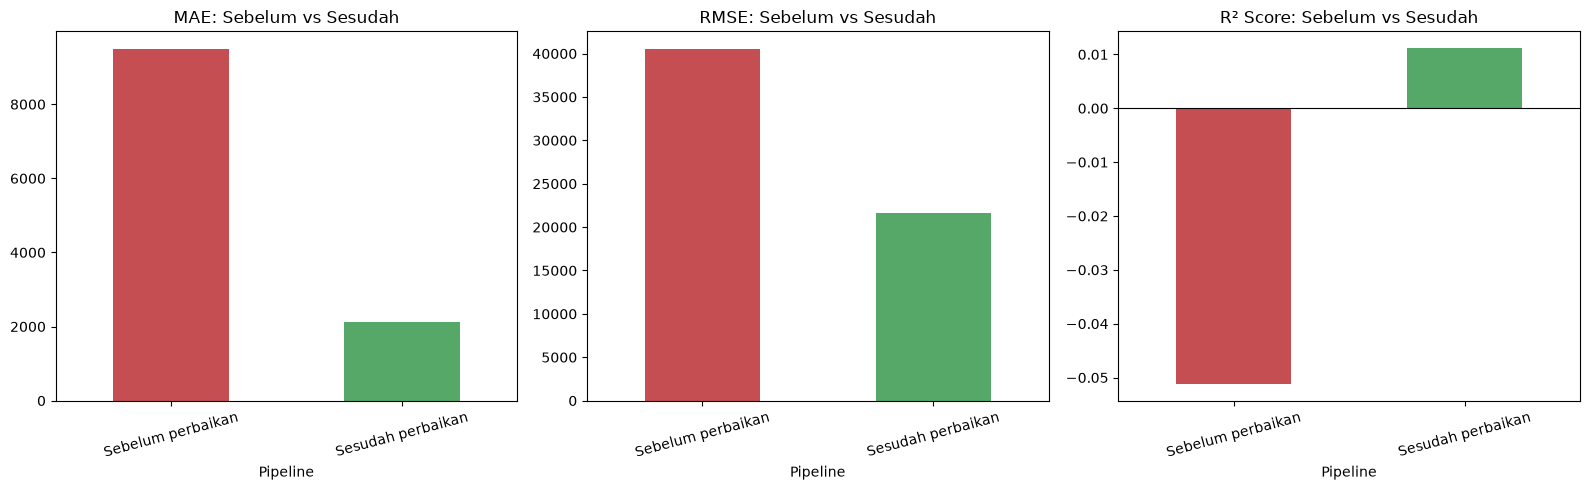

In [124]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
perbandingan_bug_df["MAE"].plot(kind="bar", ax=axes[0], color=["#C44E52", "#55A868"])
axes[0].set_title("MAE: Sebelum vs Sesudah")
axes[0].tick_params(axis="x", rotation=15)

perbandingan_bug_df["RMSE"].plot(kind="bar", ax=axes[1], color=["#C44E52", "#55A868"])
axes[1].set_title("RMSE: Sebelum vs Sesudah")
axes[1].tick_params(axis="x", rotation=15)

perbandingan_bug_df["R2 Score"].plot(kind="bar", ax=axes[2], color=["#C44E52", "#55A868"])
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("R² Score: Sebelum vs Sesudah")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "dampak_perbaikan_data.png", dpi=150)
plt.show()

In [125]:
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
hasil_tuning = []

df_tuning = df_model.sort_values("PERIOD_MO").reset_index(drop=True)
periods_t = sorted(df_tuning["PERIOD_MO"].unique())
cutoff_t = periods_t[int(len(periods_t) * 0.8)]
train_t = df_tuning[df_tuning["PERIOD_MO"] < cutoff_t]
test_t = df_tuning[df_tuning["PERIOD_MO"] >= cutoff_t]

for lr in learning_rates:
    m = GradientBoostingRegressor(n_estimators=300, learning_rate=lr, max_depth=3, random_state=42)
    m.fit(train_t[FEATURES], train_t[TARGET])
    pred_t = m.predict(test_t[FEATURES])
    hasil_tuning.append({
        "learning_rate": lr,
        "MAE": mean_absolute_error(test_t[TARGET], pred_t),
        "RMSE": np.sqrt(mean_squared_error(test_t[TARGET], pred_t)),
        "R2 Score": r2_score(test_t[TARGET], pred_t),
    })

tuning_df = pd.DataFrame(hasil_tuning)
tuning_df.to_csv(DATA_PROCESSED / "hasil_tuning_learning_rate.csv", index=False)
tuning_df.round(4)

,learning_rate,MAE,RMSE,R2 Score
0,0.01,2099.3547,21625.5587,0.0107
1,0.05,2124.5901,21620.9472,0.0112
2,0.10,2124.5903,21620.9472,0.0112
3,0.20,2124.5903,21620.9472,0.0112
4,0.30,2124.5903,21620.9472,0.0112


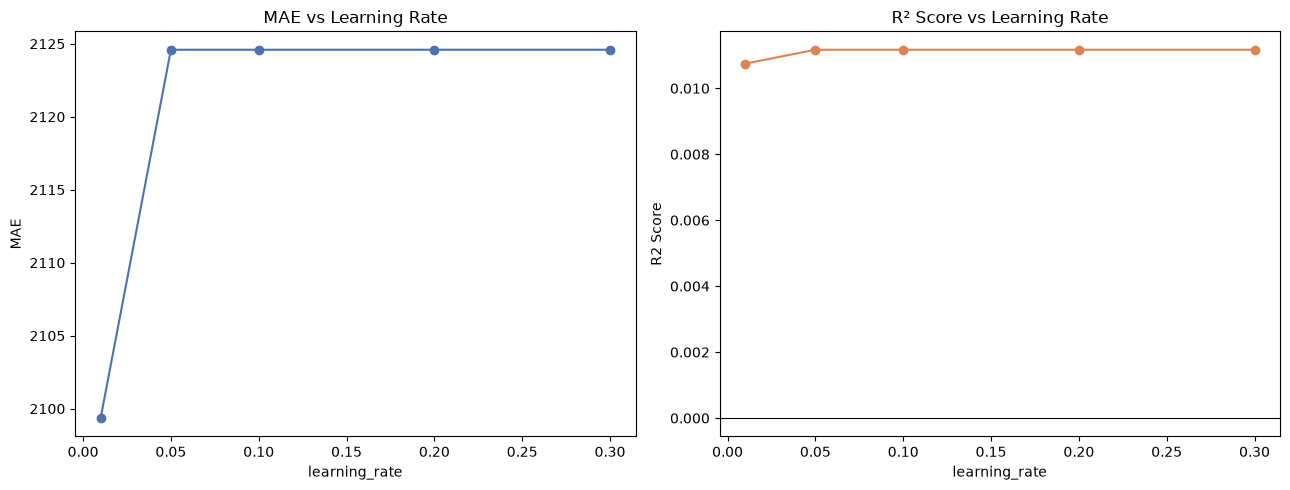

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(tuning_df["learning_rate"], tuning_df["MAE"], marker="o", color="#4C72B0")
axes[0].set_title("MAE vs Learning Rate")
axes[0].set_xlabel("learning_rate")
axes[0].set_ylabel("MAE")

axes[1].plot(tuning_df["learning_rate"], tuning_df["R2 Score"], marker="o", color="#DD8452")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("R² Score vs Learning Rate")
axes[1].set_xlabel("learning_rate")
axes[1].set_ylabel("R2 Score")

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "tuning_learning_rate.png", dpi=150)
plt.show()

In [127]:
# perbandingan ketiga algoritma yang dipake buat model, random forest, extra trees, dan gradient boosting.
models_bandingan = {
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42),
}

preds_bandingan = {}
waktu_bandingan = {}
for nama, m in models_bandingan.items():
    start_ = time.time()
    m.fit(train_t[FEATURES], train_t[TARGET])
    waktu_bandingan[nama] = time.time() - start_
    preds_bandingan[nama] = m.predict(test_t[FEATURES])
    models_bandingan[nama] = m  # simpan model yang sudah dilatih

print("Model untuk analisis mendalam sudah dilatih:", list(models_bandingan.keys()))

Model untuk analisis mendalam sudah dilatih: ['Random Forest', 'Extra Trees', 'Gradient Boosting']


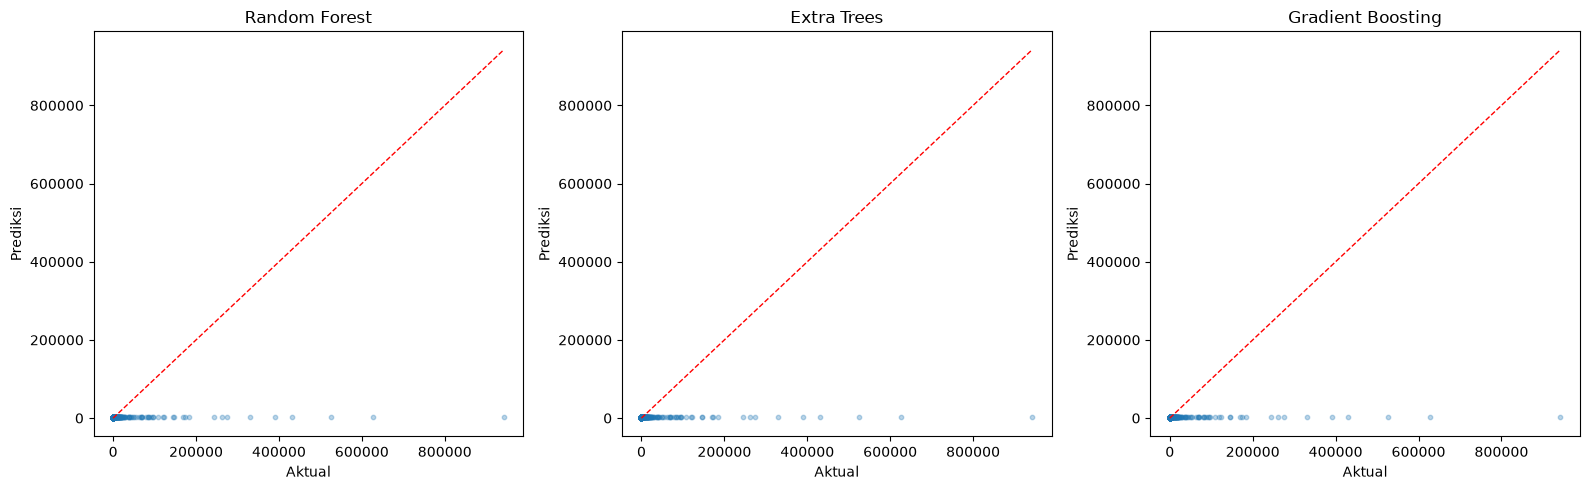

In [128]:
# aktual vs prediksi
# semakin mendekati garis hrusnya semakin bagus, kalo jauh dari garis merah berarti prediksi ga akurat
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (nama, pred) in zip(axes, preds_bandingan.items()):
    ax.scatter(test_t[TARGET], pred, alpha=0.3, s=10)
    maxval = max(test_t[TARGET].max(), pred.max())
    ax.plot([0, maxval], [0, maxval], "r--", linewidth=1)
    ax.set_title(nama)
    ax.set_xlabel("Aktual")
    ax.set_ylabel("Prediksi")

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "scatter_aktual_vs_prediksi.png", dpi=150)
plt.show()

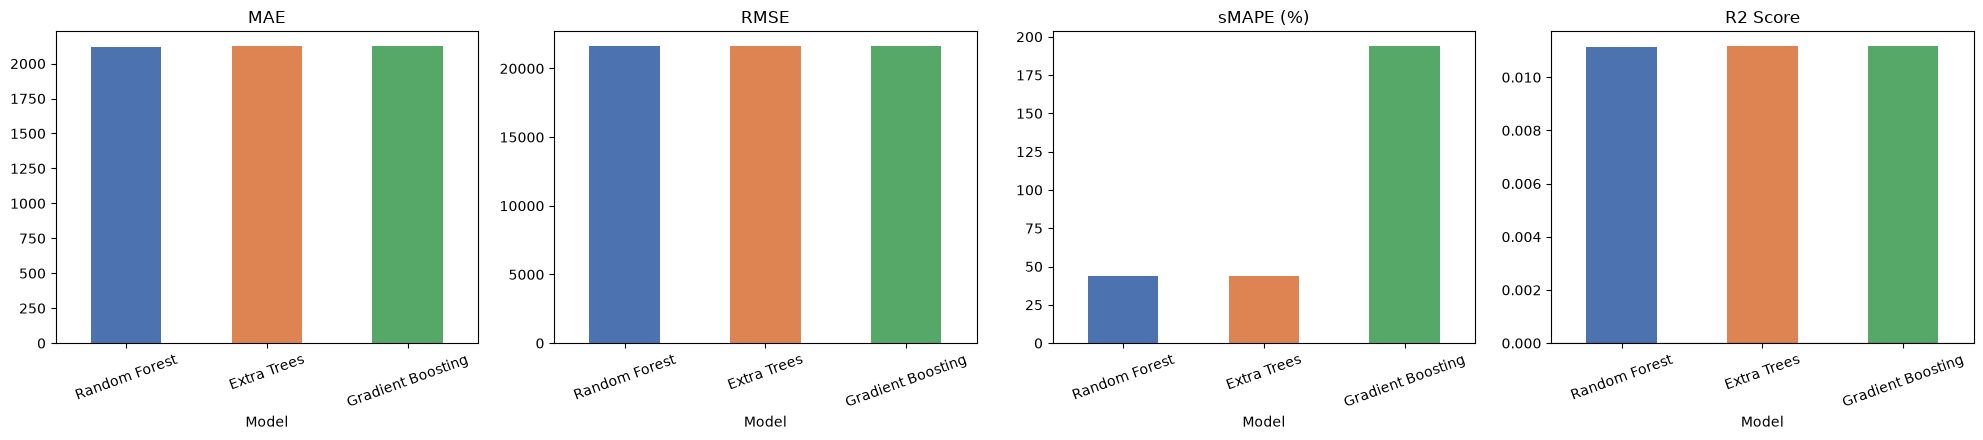

,MAE,RMSE,sMAPE (%),R2 Score
Model,,,,
Random Forest,2120.772,21621.446,43.840,0.011
Extra Trees,2124.590,21620.947,43.852,0.011
Gradient Boosting,2124.590,21620.947,193.852,0.011


In [129]:
metrik_bandingan = []
for nama, pred in preds_bandingan.items():
    metrik_bandingan.append({
        "Model": nama,
        "MAE": mean_absolute_error(test_t[TARGET], pred),
        "RMSE": np.sqrt(mean_squared_error(test_t[TARGET], pred)),
        "sMAPE (%)": smape(test_t[TARGET], pred),
        "R2 Score": r2_score(test_t[TARGET], pred),
    })
metrik_bandingan_df = pd.DataFrame(metrik_bandingan).set_index("Model")
metrik_bandingan_df.to_csv(DATA_PROCESSED / "perbandingan_4_metrik.csv")

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
warna = ["#4C72B0", "#DD8452", "#55A868"]
for ax, kolom in zip(axes, metrik_bandingan_df.columns):
    metrik_bandingan_df[kolom].plot(kind="bar", ax=ax, color=warna)
    ax.set_title(kolom)
    ax.tick_params(axis="x", rotation=20)
    if kolom == "R2 Score":
        ax.axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "perbandingan_4_metrik.png", dpi=150)
plt.show()
metrik_bandingan_df.round(3)

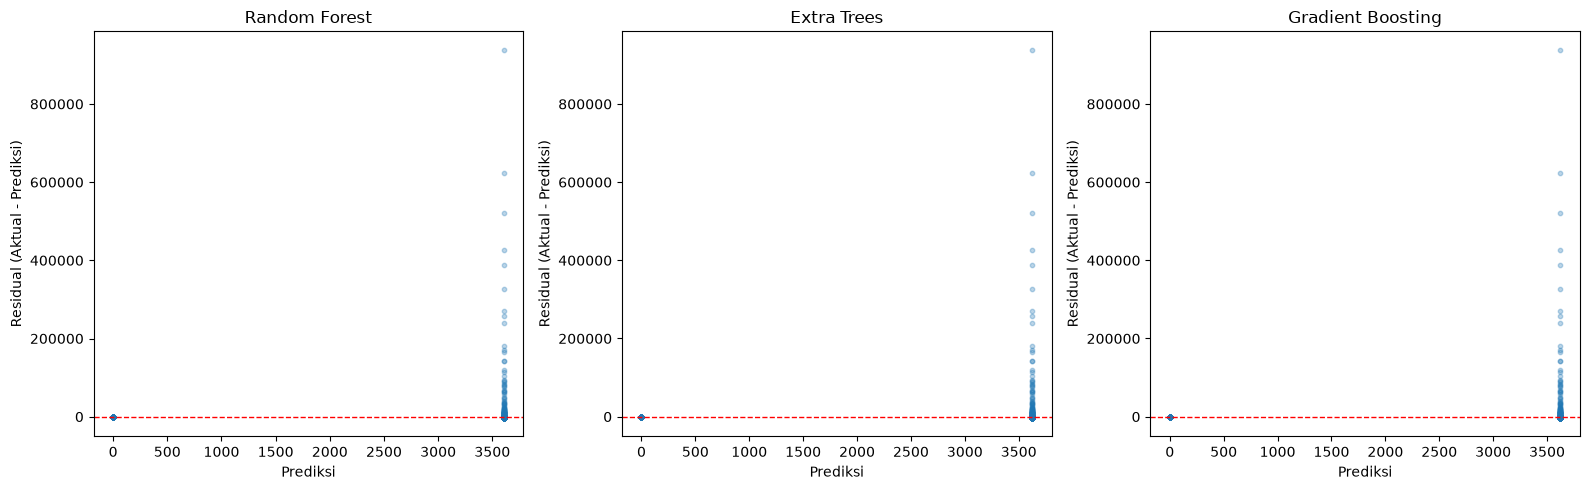

In [130]:
# titik diatas garis 0 berarti prediksi lebih kecil dari aktual, titik dibawah garis 0 berarti prediksi lebih besar dari aktual
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (nama, pred) in zip(axes, preds_bandingan.items()):
    residual = test_t[TARGET].values - pred
    ax.scatter(pred, residual, alpha=0.3, s=10)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(nama)
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Residual (Aktual - Prediksi)")

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "residual_plot.png", dpi=150)
plt.show()

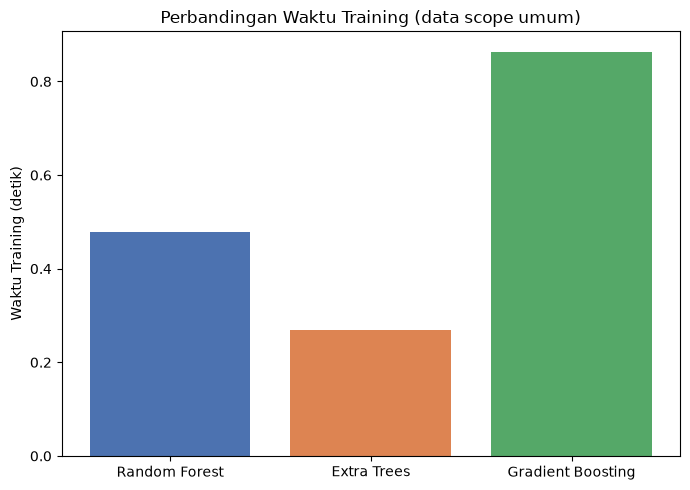

Random Forest: 0.48 detik
Extra Trees: 0.27 detik
Gradient Boosting: 0.86 detik


In [131]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(waktu_bandingan.keys(), waktu_bandingan.values(), color=warna)
ax.set_ylabel("Waktu Training (detik)")
ax.set_title("Perbandingan Waktu Training (data scope umum)")
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "perbandingan_waktu_training.png", dpi=150)
plt.show()

for nama, w in waktu_bandingan.items():
    print(f"{nama}: {w:.2f} detik")

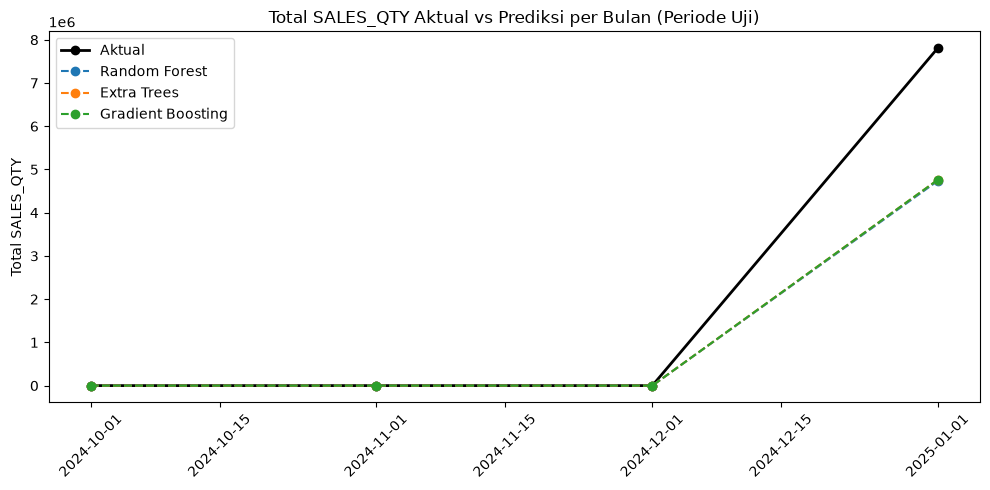

C:\Users\mmeli\AppData\Local\Temp\ipykernel_6412\2523695813.py:22: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  agg_bulanan.round(0)


,PERIOD_MO,Aktual,Random Forest,Extra Trees,Gradient Boosting
0,2024-10-01,0.0,0.0,0.0,0.0
1,2024-11-01,0.0,0.0,0.0,0.0
2,2024-12-01,0.0,0.0,0.0,0.0
3,2025-01-01,7805088.0,4734644.0,4758957.0,4758956.0


In [132]:
test_dengan_pred = test_t.copy()
for nama, pred in preds_bandingan.items():
    test_dengan_pred[nama] = pred

agg_bulanan = test_dengan_pred.groupby("PERIOD_MO").agg(
    Aktual=(TARGET, "sum"),
    **{nama: (nama, "sum") for nama in models_bandingan}
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(agg_bulanan["PERIOD_MO"], agg_bulanan["Aktual"], marker="o", label="Aktual", color="black", linewidth=2)
for nama in models_bandingan:
    ax.plot(agg_bulanan["PERIOD_MO"], agg_bulanan[nama], marker="o", label=nama, linestyle="--")

ax.set_title("Total SALES_QTY Aktual vs Prediksi per Bulan (Periode Uji)")
ax.set_ylabel("Total SALES_QTY")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "timeseries_aktual_vs_prediksi.png", dpi=150)
plt.show()
agg_bulanan.round(0)

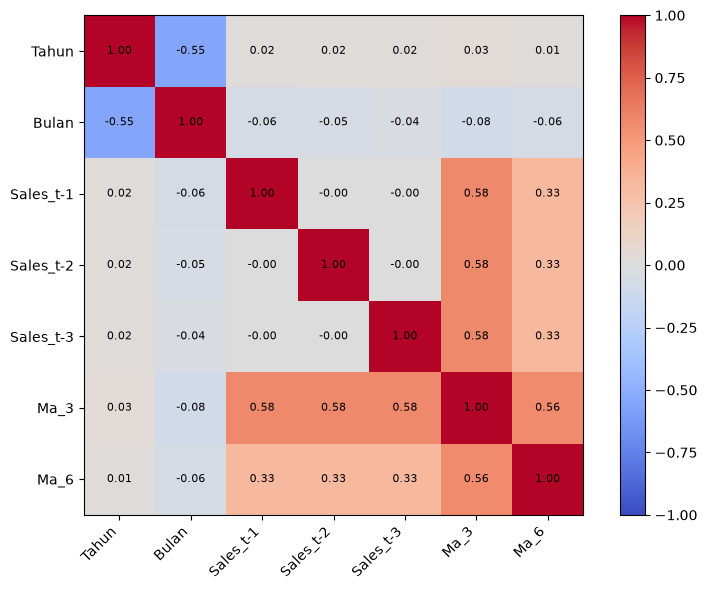

In [133]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_model[FEATURES].corr()
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels(FEATURES)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "heatmap_korelasi_fitur.png", dpi=150)
plt.show()

In [ ]:
# eksperimen hyperparameter tuning tiap model, misal random forest, extra trees, dan gradient boosting.
# pake randomized search
# validasi pake time series split
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)
N_ITER = 40  # jumlah hyperparameter yang dicoba per model

# Gunakan data scope UMUM ("ALL") sebagai basis eksperimen tuning
df_tuning8 = df_model.sort_values("PERIOD_MO").reset_index(drop=True)
periods_8 = sorted(df_tuning8["PERIOD_MO"].unique())
cutoff_8 = periods_8[int(len(periods_8) * 0.8)]
train_8 = df_tuning8[df_tuning8["PERIOD_MO"] < cutoff_8]
test_8 = df_tuning8[df_tuning8["PERIOD_MO"] >= cutoff_8]
X_train_8, y_train_8 = train_8[FEATURES], train_8[TARGET]
X_test_8, y_test_8 = test_8[FEATURES], test_8[TARGET]

In [ ]:
# tuning random forest 
param_dist_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}

search_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=N_ITER, scoring="neg_mean_absolute_error",
    cv=tscv, random_state=42, n_jobs=-1, verbose=0,
)
search_rf.fit(X_train_8, y_train_8)
print("Best params Random Forest:", search_rf.best_params_)

model_rf_default = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_train_8, y_train_8)
pred_rf_default = model_rf_default.predict(X_test_8)
pred_rf_tuned = search_rf.best_estimator_.predict(X_test_8)

In [ ]:
# tuning extra trees
param_dist_et = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}

search_et = RandomizedSearchCV(
    ExtraTreesRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist_et,
    n_iter=N_ITER, scoring="neg_mean_absolute_error",
    cv=tscv, random_state=42, n_jobs=-1, verbose=0,
)
search_et.fit(X_train_8, y_train_8)
print("Best params Extra Trees:", search_et.best_params_)

model_et_default = ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_train_8, y_train_8)
pred_et_default = model_et_default.predict(X_test_8)
pred_et_tuned = search_et.best_estimator_.predict(X_test_8)

In [ ]:
# tuning gradient boosting
param_dist_gb = {
    "n_estimators": [100, 200, 300, 500, 700, 1000],
    "learning_rate": [0.005, 0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

search_gb = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_gb,
    n_iter=N_ITER, scoring="neg_mean_absolute_error",
    cv=tscv, random_state=42, n_jobs=-1, verbose=0,
)
search_gb.fit(X_train_8, y_train_8)
print("Best params Gradient Boosting:", search_gb.best_params_)

model_gb_default = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42).fit(X_train_8, y_train_8)
pred_gb_default = model_gb_default.predict(X_test_8)
pred_gb_tuned = search_gb.best_estimator_.predict(X_test_8)

In [ ]:
# hasil misal tuning vs default model
hasil_tuning_lengkap = []
konfigurasi = {
    "Random Forest": (pred_rf_default, pred_rf_tuned, search_rf.best_params_),
    "Extra Trees": (pred_et_default, pred_et_tuned, search_et.best_params_),
    "Gradient Boosting": (pred_gb_default, pred_gb_tuned, search_gb.best_params_),
}

for nama, (pred_def, pred_tun, best_params) in konfigurasi.items():
    hasil_tuning_lengkap.append({
        "Model": nama, "Konfigurasi": "Default",
        "MAE": mean_absolute_error(y_test_8, pred_def),
        "RMSE": np.sqrt(mean_squared_error(y_test_8, pred_def)),
        "sMAPE (%)": smape(y_test_8, pred_def),
        "R2 Score": r2_score(y_test_8, pred_def),
    })
    hasil_tuning_lengkap.append({
        "Model": nama, "Konfigurasi": "Tuned (RandomizedSearchCV)",
        "MAE": mean_absolute_error(y_test_8, pred_tun),
        "RMSE": np.sqrt(mean_squared_error(y_test_8, pred_tun)),
        "sMAPE (%)": smape(y_test_8, pred_tun),
        "R2 Score": r2_score(y_test_8, pred_tun),
    })

tuning_lengkap_df = pd.DataFrame(hasil_tuning_lengkap)
tuning_lengkap_df.to_csv(DATA_PROCESSED / "hasil_tuning_sistematis.csv", index=False)

print("Best hyperparameters tiap algoritma:")
for nama, (_, _, best_params) in konfigurasi.items():
    print(f"  {nama}: {best_params}")
print()
tuning_lengkap_df.round(4)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot_mae = tuning_lengkap_df.pivot(index="Model", columns="Konfigurasi", values="MAE")
pivot_mae.plot(kind="bar", ax=axes[0], color=["#C44E52", "#55A868"])
axes[0].set_title("MAE: Default vs Tuned")
axes[0].tick_params(axis="x", rotation=15)

pivot_r2 = tuning_lengkap_df.pivot(index="Model", columns="Konfigurasi", values="R2 Score")
pivot_r2.plot(kind="bar", ax=axes[1], color=["#C44E52", "#55A868"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("R² Score: Default vs Tuned")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "hasil_tuning_sistematis.png", dpi=150)
plt.show()

In [ ]:
# eksperimen tuning terbaik + log transform buat sales qty
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

# Best hyperparameters hasil RandomizedSearchCV
BEST_PARAMS = {
    "Random Forest Regression": {
        "n_estimators": 200,
        "min_samples_split": 10,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "max_depth": 5,
    },
    "Extra Trees Regression": {
        "n_estimators": 200,
        "min_samples_split": 10,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "max_depth": 5,
    },
    "Gradient Boosting Regression": {
        "subsample": 0.6,
        "n_estimators": 300,
        "min_samples_split": 5,
        "min_samples_leaf": 1,
        "max_depth": 3,
        "learning_rate": 0.03,
    }
}


# buat model pake best hyperparameter yang udah di tuning pake randomized search
def make_tuned_model(nama_model):

    if nama_model == "Random Forest Regression":
        return RandomForestRegressor(
            **BEST_PARAMS[nama_model],
            random_state=42,
            n_jobs=-1
        )

    elif nama_model == "Extra Trees Regression":
        return ExtraTreesRegressor(
            **BEST_PARAMS[nama_model],
            random_state=42,
            n_jobs=-1
        )

    elif nama_model == "Gradient Boosting Regression":
        return GradientBoostingRegressor(
            **BEST_PARAMS[nama_model],
            random_state=42
        )


# evaluasi log tranformnya 
def evaluate_log1p(df_scope, scope):

    # Gunakan feature engineering yang sama seperti pipeline utama
    df_model, _ = build_features(
        df_scope.copy(),
        fit=True,
        verbose=False
    )

    df_model = df_model.sort_values("PERIOD_MO").reset_index(drop=True)

    unique_periods = sorted(df_model["PERIOD_MO"].unique())
    cutoff_date = unique_periods[int(len(unique_periods) * 0.8)]

    train_df = df_model[df_model["PERIOD_MO"] < cutoff_date].copy()
    test_df = df_model[df_model["PERIOD_MO"] >= cutoff_date].copy()

    X_train = train_df[FEATURES]
    X_test = test_df[FEATURES]

    y_train = train_df[TARGET]
    y_test = test_df[TARGET]

    hasil_log = []

    for nama_model in BEST_PARAMS:

        # target ga negatif
        y_train_clean = y_train.clip(lower=0)

        # tranformasi target 
        y_train_log = np.log1p(y_train_clean)

        # train model
        model = make_tuned_model(nama_model)

        start = time.time()

        model.fit(X_train, y_train_log)

        elapsed = time.time() - start

        # prediksi dalam skala log 
        y_pred_log = model.predict(X_test)

        # kembaliin ke skala sales qty asli
        y_pred = np.expm1(y_pred_log)

        # Hindari prediksi negatif akibat pembulatan numerik
        y_pred = np.maximum(y_pred, 0)

        # evaluasi pada skala asli
        mae = mean_absolute_error(y_test, y_pred)

        rmse = np.sqrt(
            mean_squared_error(y_test, y_pred)
        )

        smape_val = smape(y_test, y_pred)

        r2 = r2_score(y_test, y_pred)

        hasil_log.append({
            "Scope": scope,
            "Model": nama_model,
            "MAE": mae,
            "RMSE": rmse,
            "sMAPE (%)": smape_val,
            "R2 Score": r2,
            "Waktu Latih (s)": elapsed,
            "Jumlah Data Latih": len(train_df),
            "Transformasi": "log1p"
        })

    return hasil_log



hasil_log_all = evaluate_log1p(
    df_raw.copy(),
    scope="ALL"
)

hasil_log_df = pd.DataFrame(hasil_log_all)

hasil_log_df[
    [
        "Scope",
        "Model",
        "MAE",
        "RMSE",
        "sMAPE (%)",
        "R2 Score",
        "Waktu Latih (s)",
        "Transformasi"
    ]
]

In [141]:
# coba kalo fitur ditambahin 
# di feature engineering 


In [ ]:
# cari tau kenapa model memprediksi mendekati nilai rata-rata, tapi ga bisa prediksi nilai ekstrem (misal 0 atau 1000) dengan baik.
# Analisis apakah model cenderung memprediksi mendekati nilai tengah
model_rca = GradientBoostingRegressor(
    subsample= 0.6, n_estimators= 300, random_state=42,min_samples_split= 10, min_samples_leaf= 1, max_depth= 2, learning_rate= 0.03
)

model_rca.fit(train_t[FEATURES], train_t[TARGET])

test_rca = test_t.copy()
test_rca["pred"] = model_rca.predict(test_rca[FEATURES])

# Membagi data berdasarkan posisi nilai aktual
bins_rca = [0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.0]

labels_rca = [
    "Sangat Rendah (0–25%)",
    "Rendah (25–50%)",
    "Menengah (50–75%)",
    "Tinggi (75–90%)",
    "Sangat Tinggi (90–95%)",
    "Ekstrem Tinggi (95–99%)",
    "Sangat Ekstrem (99–100%)"
]

test_rca["kelompok"] = pd.qcut(
    test_rca[TARGET].rank(method="first"),
    q=bins_rca,
    labels=labels_rca
)

# Ringkasan untuk visualisasi
ringkasan_rca = test_rca.groupby(
    "kelompok",
    observed=True
).apply(
    lambda g: pd.Series({
        "Rata-rata Aktual": g[TARGET].mean(),
        "Rata-rata Prediksi": g["pred"].mean(),
        "Rasio Prediksi terhadap Aktual": (
            g["pred"] / g[TARGET].replace(0, np.nan)
        ).mean()
    })
)

# Simpan hasil
ringkasan_rca.to_csv(
    DATA_PROCESSED / "root_cause_underprediction.csv"
)

# Tampilkan
ringkasan_rca.round(3)

,Rata-rata Aktual,Rata-rata Prediksi,Rasio Prediksi terhadap Aktual
kelompok,,,
Sangat Rendah (0–25%),0.000,0.026,NaN
Rendah (25–50%),0.000,0.026,NaN
Menengah (50–75%),0.000,0.026,NaN
Tinggi (75–90%),27.416,3611.933,318.467
Sangat Tinggi (90–95%),225.597,3611.933,19.056
Ekstrem Tinggi (95–99%),3952.819,3611.933,2.719
Sangat Ekstrem (99–100%),130077.132,3611.933,0.074


analisis - Random Forest
                          rata_aktual  rata_prediksi     selisih  rasio_prediksi_aktual
kelompok                                                                               
Sangat Rendah (0–25%)           0.000          0.000       0.000                    NaN
Rendah (25–50%)                 0.000          0.000       0.000                    NaN
Menengah (50–75%)               0.000          0.000       0.000                    NaN
Tinggi (75–90%)                27.416       3626.558   -3599.142                319.757
Sangat Tinggi (90–95%)        225.597       3626.558   -3400.961                 19.133
Ekstrem Tinggi (95–99%)      3952.819       3626.558     326.261                  2.730
Sangat Ekstrem (99–100%)   130077.132       3626.558  126450.574                  0.075


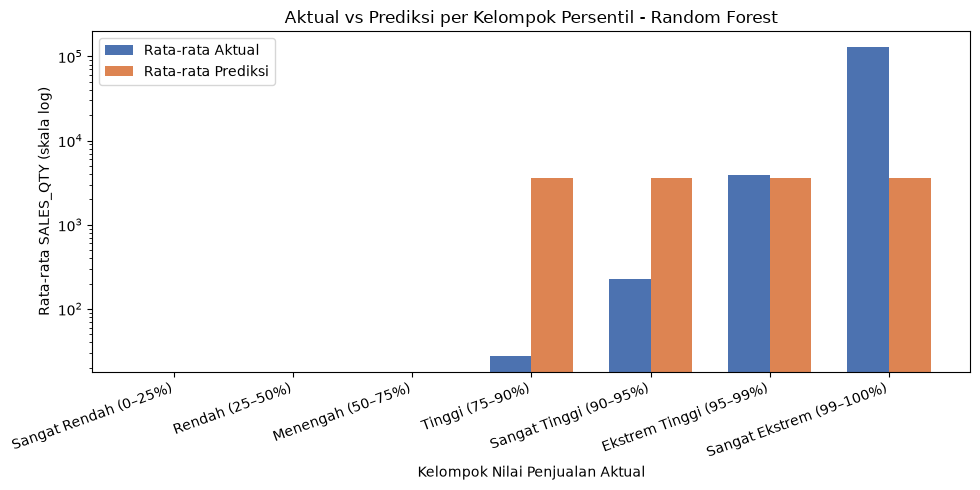

analisis - Extra Trees
                          rata_aktual  rata_prediksi     selisih  rasio_prediksi_aktual
kelompok                                                                               
Sangat Rendah (0–25%)           0.000          0.000       0.000                    NaN
Rendah (25–50%)                 0.000          0.000       0.000                    NaN
Menengah (50–75%)               0.000          0.000       0.000                    NaN
Tinggi (75–90%)                27.416       3624.491   -3597.076                319.575
Sangat Tinggi (90–95%)        225.597       3624.491   -3398.894                 19.122
Ekstrem Tinggi (95–99%)      3952.819       3624.491     328.328                  2.729
Sangat Ekstrem (99–100%)   130077.132       3624.491  126452.641                  0.075


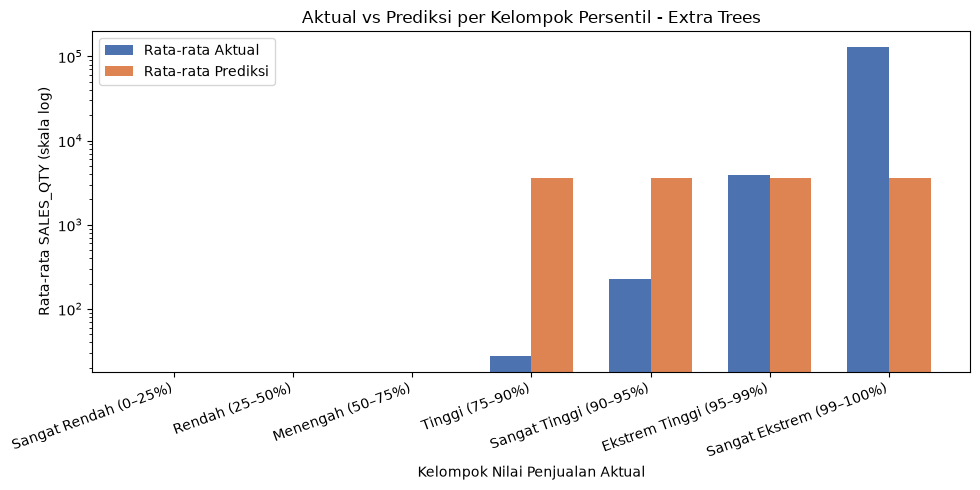

analisis - Gradient Boosting
                          rata_aktual  rata_prediksi     selisih  rasio_prediksi_aktual
kelompok                                                                               
Sangat Rendah (0–25%)           0.000           0.11      -0.110                    NaN
Rendah (25–50%)                 0.000           0.11      -0.110                    NaN
Menengah (50–75%)               0.000           0.11      -0.110                    NaN
Tinggi (75–90%)                27.416        3622.95   -3595.535                319.439
Sangat Tinggi (90–95%)        225.597        3622.95   -3397.353                 19.114
Ekstrem Tinggi (95–99%)      3952.819        3622.95     329.869                  2.728
Sangat Ekstrem (99–100%)   130077.132        3622.95  126454.182                  0.075


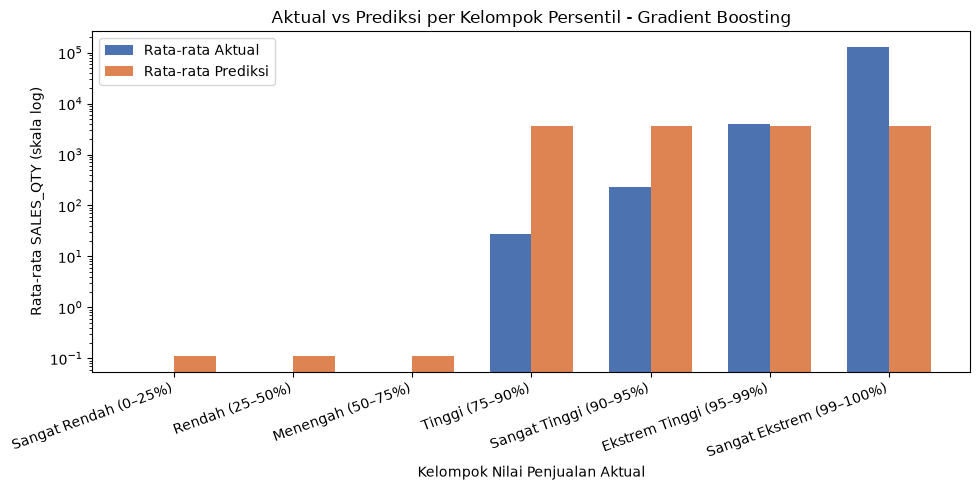

In [149]:
# cari tau kenapa model memprediksi mendekati nilai rata-rata, tapi ga bisa prediksi nilai ekstrem (misal 0 atau 1000) dengan baik.
# Analisis apakah model cenderung memprediksi mendekati nilai tengah
models_rca = {
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}


# Kelompok persentil nilai aktual
bins_rca = [0, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0]

labels_rca = [
    "Sangat Rendah (0–25%)",
    "Rendah (25–50%)",
    "Menengah (50–75%)",
    "Tinggi (75–90%)",
    "Sangat Tinggi (90–95%)",
    "Ekstrem Tinggi (95–99%)",
    "Sangat Ekstrem (99–100%)"
]


for nama_model, model_rca in models_rca.items():

    model_rca.fit(
        train_t[FEATURES],
        train_t[TARGET]
    )

    test_rca = test_t.copy()

    test_rca["pred"] = model_rca.predict(
        test_rca[FEATURES]
    )

    test_rca["kelompok"] = pd.qcut(
        test_rca[TARGET].rank(method="first"),
        q=bins_rca,
        labels=labels_rca
    )

    ringkasan_rca = test_rca.groupby(
        "kelompok",
        observed=True
    ).apply(
        lambda g: pd.Series({
            "rata_aktual": g[TARGET].mean(),
            "rata_prediksi": g["pred"].mean(),
            "selisih": (
                g[TARGET].mean() -
                g["pred"].mean()
            ),
            "rasio_prediksi_aktual": (
                g["pred"] /
                g[TARGET].replace(0, np.nan)
            ).mean()
        })
    )

    print(f"analisis - {nama_model}")

    print(
        ringkasan_rca.round(3)
    )

    nama_file = (
        nama_model
        .lower()
        .replace(" ", "_")
    )

    ringkasan_rca.to_csv(
        DATA_PROCESSED /
        f"root_cause_{nama_file}.csv"
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(labels_rca))
    width = 0.35
    ax.bar(
        x - width / 2,
        ringkasan_rca["rata_aktual"],
        width,
        label="Rata-rata Aktual",
        color="#4C72B0"
    )

    ax.bar(
        x + width / 2,
        ringkasan_rca["rata_prediksi"],
        width,
        label="Rata-rata Prediksi",
        color="#DD8452"
    )

    # Skala log
    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels(
        labels_rca,
        rotation=20,
        ha="right"
    )

    ax.set_xlabel(
        "Kelompok Nilai Penjualan Aktual"
    )

    ax.set_ylabel(
        "Rata-rata SALES_QTY (skala log)"
    )

    ax.set_title(
        f"Aktual vs Prediksi per Kelompok Persentil - {nama_model}"
    )

    ax.legend()

    plt.tight_layout()

    plt.savefig(
        DATA_PROCESSED /
        f"root_cause_{nama_file}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()